# SmartStay — Hybrid California Airbnb Recommendation System

**Project:** SmartStay  
**Team:** Aaron Hung, Louis Liu, & Jonathan Lu  
**Dataset:** `clean_ca_df.csv` (20 columns, ~50k listings)

This notebook implements a full recommendation pipeline for California Airbnb listings:

```
Section 1  — Setup & Imports
Section 2  — Load Cleaned Data
Section 3  — EDA: Distributions, Correlations, Category Counts
Section 4  — Feature Engineering: Normalize, Encode, Build Content Matrix
Section 5  — Baseline Model: Bayesian Popularity Score
Section 6  — Content-Based Model: Cosine Similarity on Feature Matrix
Section 7  — Collaborative Filtering: Item-Item KNN
Section 8  — Hybrid Model: Weighted Score Combination
Section 9  — Time-Based Extension: Recency Decay Signal
Section 10 — Evaluation: Precision@K, Coverage, Diversity, Novelty
Section 11 — Demo: Interactive Recommendation
Section 12 — (Optional) LLM Explanations
```

> **Notes:**
> - This notebook assumes `clean_ca_df.csv` is in the same directory.
> - The collaborative filtering section uses an item-item approximation (Option A) that works without user-review history
> - The time-aware model uses `reviews_per_month` as a recency proxy (Option A).

In [ ]:
# Section 1 — Setup & Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack, csr_matrix

In [ ]:
# Section 2 — Load Cleaned Data

DATA_PATH = "clean_ca_df.csv"

df = pd.read_csv(DATA_PATH, engine='python')
raw = df.copy()

print("Dataset shape:", raw.shape)
display(raw.head())
print("\nColumns:")
print(raw.columns.tolist())

Dataset shape: (247859, 20)


,id,name,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,beds,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,review_scores_rating,instant_bookable,reviews_per_month,City,bathrooms,amenities_clean
0,109,Condo in Culver City,Culver City,33.98301,-118.38607,Entire condo,Entire home/apt,6,2.0,129.0,30,730,1,2,4.00,0,0.01,los-angeles,1.0,"[Iron, Cleaning products, Microwave, Fast wifi..."
1,2708,Rental unit in Los Angeles,Hollywood,34.09625,-118.34605,Private room in rental unit,Private room,1,1.0,94.0,30,550,1,40,4.85,1,0.35,los-angeles,1.0,"[Iron, Fire pit, Self check-in, Cleaning produ..."
2,2732,Rental unit in Santa Monica,Santa Monica,34.00440,-118.48095,Private room in rental unit,Private room,1,1.0,179.0,7,27,1,24,4.41,0,0.16,los-angeles,2.0,"[Sound system, Gas stove, Iron, Drying rack fo..."
3,2864,Rental unit in Bellflower,Bellflower,33.87490,-118.11515,Entire rental unit,Entire home/apt,2,1.0,50.0,30,730,0,0,0.00,0,0.00,los-angeles,1.0,"[Samsung refrigerator, Thermador stainless ste..."
4,63416,Home in Hollywood,Hollywood Hills,34.11344,-118.32399,Private room in home,Private room,3,2.0,220.0,2,365,1,161,4.99,0,1.02,los-angeles,1.5,"[Gas stove, Iron, Drying rack for clothing, Cl..."



Columns:
['id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'reviews_per_month', 'City', 'bathrooms', 'amenities_clean']


## Section 3 — EDA: Distributions, Correlations, Category Counts

Before building any model, we need to understand the shape of the data. Even though cleaning is done, questions remain:

- Are prices normally distributed or heavily skewed? (Affects whether we normalize linearly or log-scale)
- Are certain room types extremely dominant? (Affects how much discriminating power the categorical feature carries)
- Are there correlations between features that would cause redundancy in the model?

Skipping EDA and going straight to modeling is a common mistake — a model may technically run but be dominated by a single poorly-scaled feature without anyone noticing.

In [ ]:
# Basic summary statistics

display(raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,247859.0,NaN,NaN,NaN,343867511645192576.0,404407285445144064.0,6.0,27726400.0,51033249.0,769658761398785024.0,1105980075182176640.0
name,247859,10303,Home in Los Angeles,24173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_cleansed,247859,558,San Jose,8833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,247859.0,NaN,NaN,NaN,34.933394,1.810678,32.53557,33.98084,34.090993,37.335011,37.88162
longitude,247859.0,NaN,NaN,NaN,-119.341854,1.96594,-122.51904,-121.96143,-118.3827,-118.172575,-116.93425
property_type,247859,125,Entire home,60474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,247859,4,Entire home/apt,179012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,247859.0,NaN,NaN,NaN,3.970221,2.818883,0.0,2.0,3.0,5.0,16.0
beds,247859.0,NaN,NaN,NaN,2.22207,1.746746,0.0,1.0,2.0,3.0,50.0
price,247859.0,NaN,NaN,NaN,281.203043,987.420902,0.0,95.0,150.0,255.0,99999.0


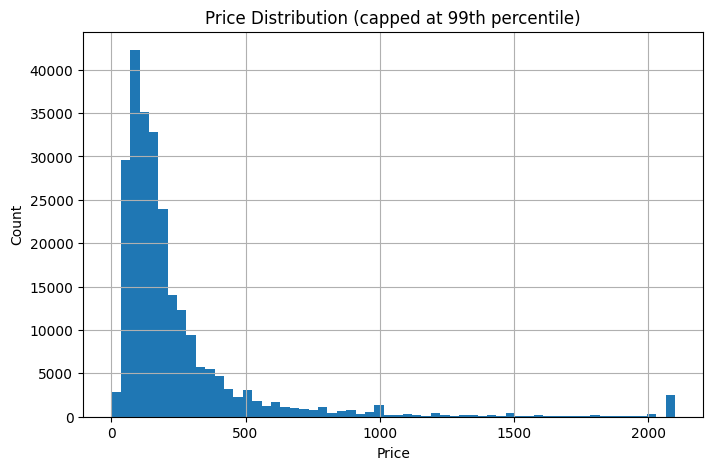

In [ ]:
# Price distribution (capped at 99th percentile)
# Why: Airbnb prices are right-skewed — a few $5000/night listings pull the mean up.
# Capping at the 99th percentile prevents outliers from dominating the axis scale.

price_cap = raw["price"].quantile(0.99)

plt.figure(figsize=(8, 5))
raw["price"].clip(upper=price_cap).hist(bins=60)
plt.title("Price Distribution (capped at 99th percentile)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

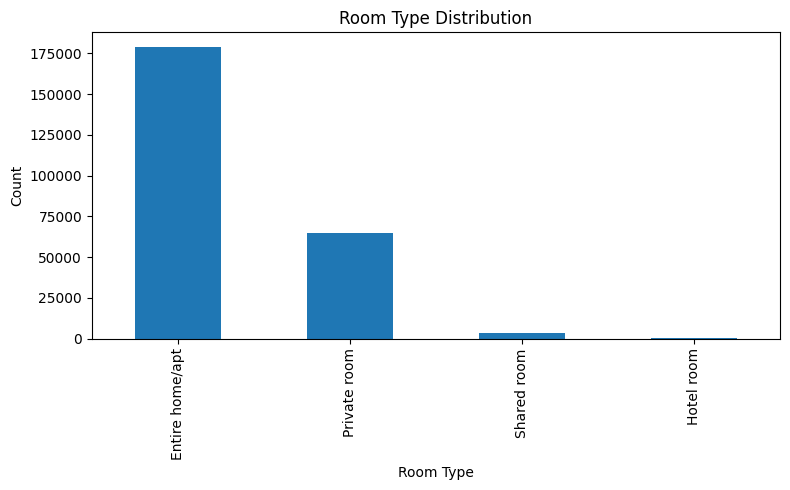

In [ ]:
# Room type distribution
# Why: If 90% of listings are "Entire home/apt", the room_type feature will have
# very little discriminating power for most users.

plt.figure(figsize=(8, 5))
raw["room_type"].value_counts().plot(kind="bar")
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

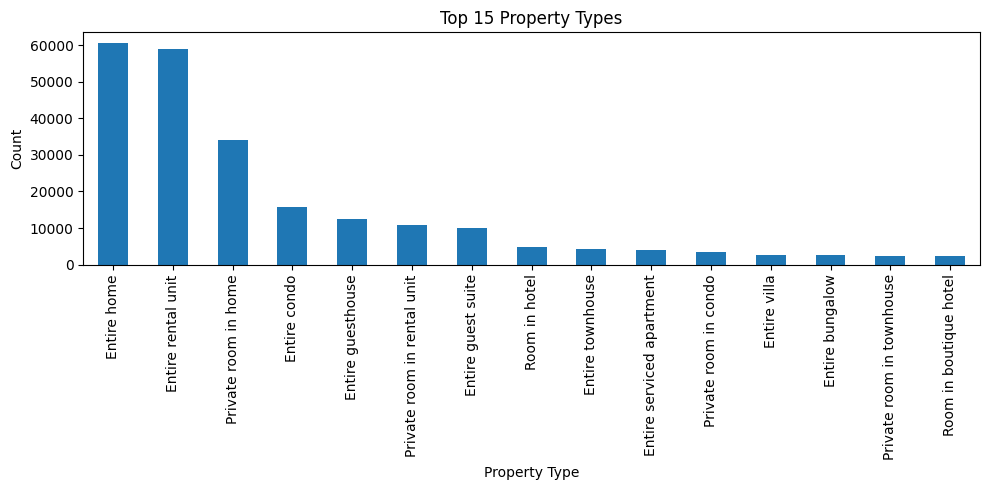

In [ ]:
# Top 15 property types

plt.figure(figsize=(10, 5))
raw["property_type"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Property Types")
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

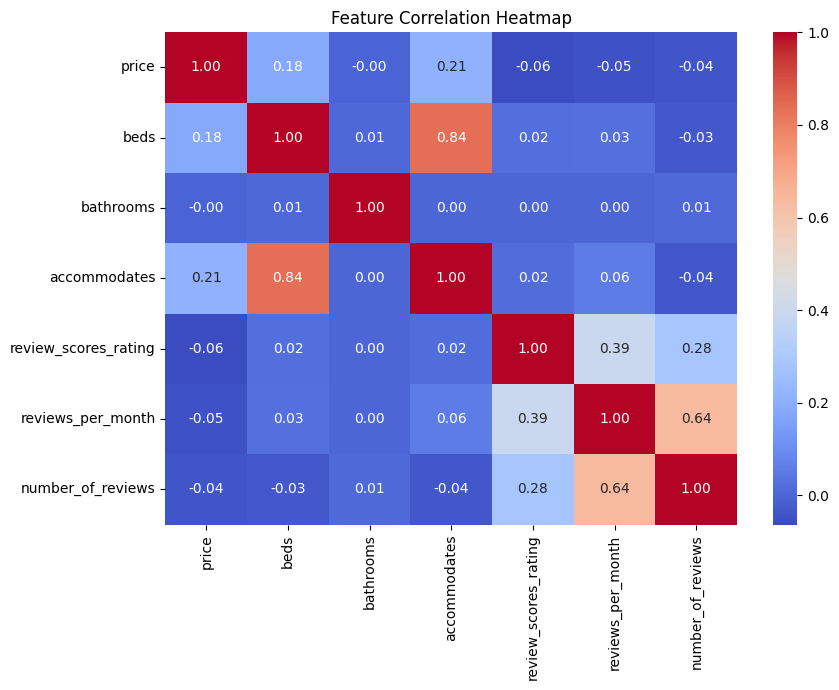

In [ ]:
# Correlation heatmap
# Why: If 'beds' and 'accommodates' are highly correlated (which they likely are),
# including both adds noise without adding information. We may choose to drop one.

corr_cols = [
    "price", "beds", "bathrooms", "accommodates",
    "review_scores_rating", "reviews_per_month", "number_of_reviews"
]

plt.figure(figsize=(9, 7))
sns.heatmap(raw[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Section 4 — Feature Engineering: Normalize, Encode, Build Content Matrix

We build a combined feature representation for each listing using three types of features:

- **Numeric features** (normalized): price, beds, bathrooms, accommodates, review score, lat/lon
- **Categorical features** (one-hot encoded): room type, property type
- **Amenity text features** (TF-IDF): parsed amenity strings

**Key decision:** We keep `raw` (unscaled) and the transformed matrices as separate objects throughout the project.
- `raw` is used for displaying results and applying hard price/city filters
- The scaled matrices are used inside all model math

The `scaler` and `tfidf` objects **must** be fit once here and reused everywhere. Re-fitting them in a later cell would break alignment between the user preference vector and the listing matrix.

In [ ]:
# Numeric feature normalization
# Why normalize? Cosine similarity is sensitive to scale.
# A price of $300 vs $10 would dominate over a rating of 4.5 vs 3.0
# if we don't bring all features to the same 0-1 range.
# Note: reviews_per_month is kept in raw for the time-based model but is not
# part of the content feature vector — it would add noise without adding
# meaningful structural similarity between listings.

num_cols = [
    "price", "beds", "bathrooms", "accommodates",
    "review_scores_rating"
]

for col in num_cols:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

scaler = MinMaxScaler()
num_matrix = scaler.fit_transform(raw[num_cols].fillna(0))

print("Numeric matrix shape:", num_matrix.shape)


Numeric matrix shape: (247859, 5)


In [ ]:
# Categorical feature encoding
# Why one-hot encode? Room type and property type are discrete categories with no
# inherent order — "Entire home" and "Shared room" are orthogonal concepts, not
# a numeric ranking. One-hot encoding treats them as independent binary dimensions.

cat_source_cols = ["room_type", "property_type"]
cat_df = pd.get_dummies(raw[cat_source_cols].fillna("Unknown"), drop_first=False)
cat_cols = cat_df.columns.tolist()
cat_matrix = cat_df.values

print("Categorical matrix shape:", cat_matrix.shape)
print("Number of categorical columns:", len(cat_cols))

Categorical matrix shape: (247859, 129)
Number of categorical columns: 129


In [ ]:
# Amenity TF-IDF features
# Why TF-IDF instead of just counting amenities?
# TF-IDF down-weights amenities that appear in almost every listing (e.g. "wifi")
# and up-weights rare but meaningful ones (e.g. "hot tub", "EV charger").
# This way matching on "hot tub" contributes more than matching on "wifi".

tfidf = TfidfVectorizer(max_features=100, stop_words="english")
amenity_matrix = tfidf.fit_transform(raw["amenities_clean"].fillna(""))

print("Amenity matrix shape:", amenity_matrix.shape)

Amenity matrix shape: (247859, 100)


In [ ]:
# Final content matrix — stack all feature types horizontally
# Each row = one listing represented as a single feature vector.
# Why sparse? The TF-IDF matrix is already sparse (most listings mention only a
# small fraction of the 100-token vocabulary). Keeping everything as csr_matrix
# avoids materializing a dense 50k × (7 + cats + 100) float array.

content_matrix = hstack([
    csr_matrix(num_matrix),
    csr_matrix(cat_matrix),
    amenity_matrix
])

print("Content matrix shape:", content_matrix.shape)

Content matrix shape: (247859, 234)


## Section 5 — Baseline Model: Bayesian Popularity Score

Every recommender system needs a **baseline** — a naive model that requires no machine learning. Its purpose is not to be good; its purpose is to be a reference point to beat.

**Why not just sort by review count?**  
Sorting by `number_of_reviews` alone is flawed: a listing with 1000 reviews and a 3.5 rating would rank above one with 50 reviews and a 4.9 rating.

We use a **Bayesian average** instead, which blends each listing's own rating with the global average, weighted by how many reviews it has. A listing needs to *earn* its high rank with enough evidence.

```
score = (v / (v + m)) × R + (m / (v + m)) × C

Where:
  v = number of reviews for this listing
  m = minimum reviews required (25th percentile threshold)
  R = this listing's average rating
  C = global average rating across all listings
```

When `v` is small, the score pulls toward `C` (conservative). When `v` is large, the score reflects the listing's actual rating `R`.

In [ ]:
# Bayesian popularity score

C = raw["review_scores_rating"].fillna(raw["review_scores_rating"].mean()).mean()
m = raw["number_of_reviews"].fillna(0).quantile(0.25)

def bayesian_score(row, C=C, m=m):
    v = row["number_of_reviews"]
    R = row["review_scores_rating"]
    if pd.isna(v):
        v = 0
    if pd.isna(R):
        R = C
    return (v / (v + m + 1e-9)) * R + (m / (v + m + 1e-9)) * C

raw["popularity_score"] = raw.apply(bayesian_score, axis=1)

display(raw[["name", "City", "price", "review_scores_rating", "number_of_reviews", "popularity_score"]].head())

,name,City,price,review_scores_rating,number_of_reviews,popularity_score
0,Condo in Culver City,los-angeles,129.0,4.00,2,3.876492
1,Rental unit in Los Angeles,los-angeles,94.0,4.85,40,4.820231
2,Rental unit in Santa Monica,los-angeles,179.0,4.41,24,4.378779
3,Rental unit in Bellflower,los-angeles,50.0,0.00,0,3.629477
4,Home in Hollywood,los-angeles,220.0,4.99,161,4.981602


In [ ]:
def recommend_popular(budget_max=None, city=None, room_type=None, top_n=10):
    """
    Hard filters (budget, city, room type) are applied first, then rank by
    Bayesian popularity score.
    Hard filters must come before ranking — we should never recommend a listing
    the user literally cannot afford or that is in the wrong city.
    """
    filtered = raw.copy()

    if budget_max is not None:
        filtered = filtered[filtered["price"] <= budget_max]
    if city:
        filtered = filtered[filtered["City"].fillna("").str.lower() == city.lower()]
    if room_type:
        filtered = filtered[filtered["room_type"] == room_type]

    cols = ["id", "name", "City", "room_type", "price", "review_scores_rating", "number_of_reviews", "popularity_score"]
    return filtered.nlargest(top_n, "popularity_score")[cols]

In [ ]:
# Top 5 places in Los Angeles
display(recommend_popular(budget_max=300, city="los-angeles", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
14501,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,450,4.996961
127695,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,450,4.996961
96922,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,443,4.996913
5712,16069685,Guesthouse in Whittier,los-angeles,Entire home/apt,130.0,5.0,401,4.996591
130269,16069685,Guesthouse in Whittier,los-angeles,Entire home/apt,130.0,5.0,386,4.996459


In [ ]:
# Top 5 places in Oakland
display(recommend_popular(budget_max=300, city="oakland", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
46246,22496831,Rental unit in Oakland,oakland,Entire home/apt,118.0,5.0,216,4.993684
171617,22496831,Rental unit in Oakland,oakland,Entire home/apt,119.0,5.0,207,4.993411
174223,22496831,Rental unit in Oakland,oakland,Entire home/apt,125.0,5.0,207,4.993411
46462,32744436,Home in Oakland,oakland,Entire home/apt,161.0,5.0,119,4.988579
174443,32744436,Home in Oakland,oakland,Entire home/apt,170.0,5.0,113,4.987978


In [ ]:
# Top 5 places in Pacific Grove
display(recommend_popular(budget_max=300, city="pacific-grove", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
48526,587711256303177865,Home in Pacific Grove,pacific-grove,Private room,260.0,5.0,250,4.994540
176635,587711256303177865,Home in Pacific Grove,pacific-grove,Private room,276.0,5.0,206,4.993379
48381,14388930,Guest suite in Pacific Grove,pacific-grove,Entire home/apt,195.0,5.0,94,4.985573
48395,19137340,Home in Pacific Grove,pacific-grove,Entire home/apt,150.0,5.0,90,4.984939
176488,14388930,Guest suite in Pacific Grove,pacific-grove,Entire home/apt,215.0,5.0,90,4.984939


In [ ]:
# Top 5 places in San Diego
display(recommend_popular(budget_max=300, city="san-diego", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
50409,18958877,Guesthouse in San Diego,san-diego,Entire home/apt,192.0,5.0,440,4.996892
190757,18958877,Guesthouse in San Diego,san-diego,Entire home/apt,198.0,5.0,430,4.996820
178574,18958877,Guesthouse in San Diego,san-diego,Entire home/apt,205.0,5.0,413,4.996690
49517,10307039,Home in San Diego,san-diego,Entire home/apt,171.0,5.0,296,4.995385
189920,10307039,Home in San Diego,san-diego,Entire home/apt,182.0,5.0,291,4.995306


In [ ]:
# Top 5 places in San Francisco
display(recommend_popular(budget_max=300, city="san-francisco", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
63199,856123,Private Suite in a Stunning Vegan Penthouse,san-francisco,Private room,129.0,5.0,284,4.995191
216268,856123,Condo in San Francisco,san-francisco,Private room,121.0,5.0,277,4.995070
208845,856123,Condo in San Francisco,san-francisco,Private room,135.0,5.0,260,4.994749
63568,4987668,Petite room in a Vegan Mission Penthouse,san-francisco,Private room,88.0,5.0,246,4.994451
202493,856123,Condo in San Francisco,san-francisco,Private room,103.0,5.0,244,4.994406


In [ ]:
# Top 5 places in San Mateo County
display(recommend_popular(budget_max=300, city="san-mateo-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
70709,32472845,Guest suite in El Granada,san-mateo-county,Entire home/apt,185.0,5.0,312,4.995621
228390,32472845,Guest suite in El Granada,san-mateo-county,Entire home/apt,188.0,5.0,294,4.995354
225068,32472845,Guest suite in El Granada,san-mateo-county,Entire home/apt,192.0,5.0,274,4.995016
70541,26847871,Guesthouse in Woodside,san-mateo-county,Entire home/apt,294.0,5.0,267,4.994886
228218,26847871,Guesthouse in Woodside,san-mateo-county,Entire home/apt,294.0,5.0,256,4.994667


In [ ]:
# Top 5 places in Santa Clara County
display(recommend_popular(budget_max=300, city="santa-clara-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
73352,1024086,Guesthouse in Los Gatos,santa-clara-county,Entire home/apt,88.0,5.0,230,4.994067
230993,1024086,Guesthouse in Los Gatos,santa-clara-county,Entire home/apt,88.0,5.0,230,4.994067
237629,1024086,Guesthouse in Los Gatos,santa-clara-county,Entire home/apt,88.0,5.0,230,4.994067
231721,15072431,Home in San Jose,santa-clara-county,Entire home/apt,178.0,5.0,179,4.992386
74352,20287745,Home in Palo Alto,santa-clara-county,Entire home/apt,296.0,5.0,149,4.990863


In [ ]:
# Top 5 places in Santa Cruz County
display(recommend_popular(budget_max=300, city="santa-cruz-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
81197,51828433,Home in Capitola,santa-cruz-county,Entire home/apt,250.0,5.00,152,4.991042
80779,30585288,Tiny home in Scotts Valley,santa-cruz-county,Entire home/apt,213.0,5.00,147,4.990740
246755,30585288,Tiny home in Scotts Valley,santa-cruz-county,Entire home/apt,216.0,5.00,135,4.989923
245054,30585288,Tiny home in Scotts Valley,santa-cruz-county,Entire home/apt,199.0,5.00,127,4.989293
80356,6004171,Guest suite in Aptos,santa-cruz-county,Entire home/apt,178.0,4.99,685,4.988017


## Section 6 — Content-Based Model: Cosine Similarity on Feature Matrix

The popularity model ignores the user entirely — everyone gets the same rankings. Content-based filtering personalizes by treating each listing as a feature vector and finding listings most similar to what the user described.

**The core question it answers:** "Given that a user wants X, which listings look most like X?"

**Why cosine similarity?**  
We represent both listings and user preferences as vectors in the same feature space. Cosine similarity measures the *angle* between two vectors, not the magnitude. This is ideal because:
- A 500 dollar listing and a 100 dollar listing with identical proportional features should be considered structurally similar, not penalized by absolute price differences
- It handles sparse high-dimensional vectors (like TF-IDF) better than Euclidean distance


In [ ]:
def build_user_vector(
    price,
    beds,
    bathrooms,
    accommodates,
    min_rating,
    room_type,
    property_type,
    amenities_str
):
    """
    Converts raw user inputs into the same vector format as the listing content matrix.
    Must use the same scaler and tfidf objects fit in Section 4 — do not refit them.
    """

    user_num_df = pd.DataFrame([[
        price, beds, bathrooms, accommodates, min_rating
    ]], columns=num_cols)

    user_num = scaler.transform(user_num_df.fillna(0))

    user_cat = np.zeros((1, len(cat_cols)))
    for col in [f"room_type_{room_type}", f"property_type_{property_type}"]:
        if col in cat_cols:
            user_cat[0, cat_cols.index(col)] = 1

    user_amenity = tfidf.transform([amenities_str if amenities_str else ""])

    return hstack([csr_matrix(user_num), csr_matrix(user_cat), user_amenity])

In [ ]:
def recommend_content(user_vector, budget_max=None, city=None, room_type=None, top_n=10):
    """
    Compute similarity between the user vector and every listing, then apply hard filters.
    Hard filters are applied after scoring so the model sees the full landscape first.
    """
    scores = cosine_similarity(user_vector, content_matrix).flatten()

    results = raw.copy()
    results["content_score"] = scores

    if budget_max is not None:
        results = results[results["price"] <= budget_max]
    if city:
        results = results[results["City"].fillna("").str.lower() == city.lower()]
    if room_type:
        results = results[results["room_type"] == room_type]

    cols = ["id", "name", "City", "room_type", "price", "review_scores_rating", "content_score"]
    return results.nlargest(top_n, "content_score")[cols]


# Sample user preference vector (used throughout the rest of the notebook)
sample_user_vector = build_user_vector(
    price=300,
    beds=2,
    bathrooms=1,
    accommodates=4,
    min_rating=4.5,
    room_type="Entire home/apt",
    property_type="Entire rental unit",
    amenities_str="wifi kitchen parking air conditioning"
)


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="los-angeles", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
159344,44906916,Rental unit in Los Angeles,los-angeles,Entire home/apt,131.0,3.91,0.954831
88118,17015994,Rental unit in Los Angeles,los-angeles,Entire home/apt,150.0,4.84,0.945521
93019,28744991,Rental unit in Los Angeles,los-angeles,Entire home/apt,209.0,5.00,0.944242
12674,34022580,Rental unit in Los Angeles,los-angeles,Entire home/apt,210.0,4.89,0.939550
101804,48299336,Rental unit in Los Angeles,los-angeles,Entire home/apt,150.0,3.00,0.938811


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="oakland", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
174072,17829977,Rental unit in Berkeley,oakland,Entire home/apt,149.0,4.91,0.937042
46365,28284045,Rental unit in Oakland,oakland,Entire home/apt,90.0,4.79,0.929136
175070,51655988,Rental unit in Oakland,oakland,Entire home/apt,96.0,4.86,0.917119
172691,564060154423964280,Rental unit in Oakland,oakland,Entire home/apt,100.0,4.79,0.914613
171044,1537027,Rental unit in Oakland,oakland,Entire home/apt,250.0,4.83,0.914267


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="pacific-grove", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
176588,44808129,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,99.0,4.90,0.855655
176531,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,266.0,4.94,0.842525
176380,50462307,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,178.0,4.67,0.822586
48478,44808129,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,60.0,4.92,0.807612
48485,46454838,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,126.0,4.91,0.807471


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="san-diego", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
185083,644966796227061115,Rental unit in San Diego,san-diego,Entire home/apt,241.0,4.08,0.942185
57871,786861099278366094,Rental unit in San Diego,san-diego,Entire home/apt,125.0,4.91,0.935341
193523,43725063,Rental unit in San Diego,san-diego,Entire home/apt,125.0,4.64,0.929634
192230,33398238,Rental unit in San Diego,san-diego,Entire home/apt,185.0,4.83,0.927650
61012,1009390232055924530,Rental unit in San Diego,san-diego,Entire home/apt,76.0,5.00,0.917847


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="san-francisco", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
61567,21739662,Remodeled Studio Near Union Square!,san-francisco,Entire home/apt,73.0,4.38,0.927148
61478,51557,Centrally Located Victorian Apartment,san-francisco,Entire home/apt,125.0,4.89,0.923205
218158,23150717,Rental unit in San Francisco,san-francisco,Entire home/apt,180.0,4.97,0.922095
66669,39422632,Cozy oasis in the heart of San Francisco,san-francisco,Entire home/apt,160.0,5.00,0.902605
61503,22652071,Well Located and Economical 2 Bedroom,san-francisco,Entire home/apt,125.0,4.75,0.898284


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="san-mateo-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
70149,15512753,Rental unit in El Granada,san-mateo-county,Entire home/apt,159.0,4.96,0.891549
72692,918391755250037183,Rental unit in San Carlos,san-mateo-county,Entire home/apt,132.0,5.00,0.881467
71691,546479134299198232,Rental unit in San Mateo,san-mateo-county,Entire home/apt,96.0,4.75,0.859441
226043,53244889,Rental unit in Daly City,san-mateo-county,Entire home/apt,150.0,4.73,0.857611
225959,52423182,Rental unit in Burlingame,san-mateo-county,Entire home/apt,124.0,4.85,0.857408


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="santa-clara-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
74560,23801654,Rental unit in San Jose,santa-clara-county,Entire home/apt,92.0,4.23,0.976089
75482,40344542,Rental unit in Mountain View,santa-clara-county,Entire home/apt,111.0,4.58,0.936268
77012,576814031921455086,Rental unit in San Jose,santa-clara-county,Entire home/apt,150.0,4.94,0.925114
234083,49548861,Rental unit in Santa Clara,santa-clara-county,Entire home/apt,197.0,4.97,0.919087
236698,842423313484901098,Rental unit in Palo Alto,santa-clara-county,Entire home/apt,189.0,5.00,0.912802


In [ ]:
display(recommend_content(sample_user_vector, budget_max=300, city="santa-cruz-county", top_n=5))

,id,name,City,room_type,price,review_scores_rating,content_score
81736,958573014335628101,Rental unit in Capitola,santa-cruz-county,Entire home/apt,250.0,4.88,0.878859
80422,8471582,Rental unit in Santa Cruz,santa-cruz-county,Entire home/apt,229.0,4.93,0.877744
244616,7515729,Rental unit in Santa Cruz,santa-cruz-county,Entire home/apt,167.0,4.49,0.861340
246986,44571722,Rental unit in Watsonville,santa-cruz-county,Entire home/apt,225.0,4.47,0.861337
247794,940559562954125490,Rental unit in Capitola,santa-cruz-county,Entire home/apt,143.0,4.60,0.861298


## Section 7 — Collaborative Filtering: Item-Item KNN

Content-based filtering only looks at listing features — it ignores collective human behavior. Collaborative filtering asks a different question: **"What did similar users or listings do?"**

The insight is that if users A and B have similar tastes, and A liked listing X, then B probably would too — even if listing X doesn't perfectly match B's stated preferences. This captures patterns that pure feature similarity cannot.

**The data problem:**  
`clean_ca_df.csv` contains aggregated review counts per listing, not individual reviewer interactions. We address this with two options:

- **Option A (used here):** Item-item CF using feature similarity as a proxy. This is technically feature-based item similarity, but it captures the same "similar listings" idea without requiring user history. Implemented via `sklearn.neighbors.NearestNeighbors` to avoid storing a full 50k×50k similarity matrix in memory.
- **Option B:** True user-item CF using `reviews.csv` from Kaggle. Stubbed out below — use if the file is available.

> **Recommendation:** Use Option A first to get a working system, then swap in Option B if time permits.

In [ ]:
# Option A — Item-item CF using NearestNeighbors on the content matrix
# Why NearestNeighbors instead of computing the full cosine_similarity matrix?
# A full pairwise similarity matrix on 50k listings would be 50k×50k ≈ 20GB.
# NearestNeighbors with algorithm='brute' computes similarity on demand per query
# without materializing the full matrix.

item_nn = NearestNeighbors(metric="cosine", algorithm="brute")
item_nn.fit(content_matrix)

def recommend_similar_listings(listing_id, top_n=10):
    """
    Given a listing the user liked or is viewing, find the most similar other listings.
    This is the 'customers also viewed' pattern.
    """
    match = raw.index[raw["id"] == listing_id]
    if len(match) == 0:
        raise ValueError(f"Listing id {listing_id} not found.")

    idx = match[0]
    distances, indices = item_nn.kneighbors(content_matrix[idx], n_neighbors=top_n + 1)

    neighbor_idx = indices.flatten()[1:]    # drop self (always similarity=1.0 with itself)
    neighbor_dist = distances.flatten()[1:]

    results = raw.iloc[neighbor_idx][["id", "name", "City", "room_type", "price", "review_scores_rating"]].copy()
    results["collab_score"] = 1 - neighbor_dist   # convert cosine distance → similarity
    return results.sort_values("collab_score", ascending=False)

example_listing_id = raw.iloc[0]["id"]
display(recommend_similar_listings(example_listing_id, top_n=10))

,id,name,City,room_type,price,review_scores_rating,collab_score
213100,49593662,Condo in San Francisco,san-francisco,Entire home/apt,125.0,5.00,0.987250
1387,3259139,Condo in Pasadena,los-angeles,Entire home/apt,235.0,4.70,0.968674
58297,817484592005308562,Condo in San Diego,san-diego,Entire home/apt,432.0,4.67,0.967375
242355,740502617551333943,Condo in San Jose,santa-clara-county,Entire home/apt,195.0,4.96,0.962518
56404,644229033108135383,Condo in San Diego,san-diego,Entire home/apt,126.0,4.30,0.962390
208162,43220752,Condo in San Francisco,san-francisco,Entire home/apt,149.0,4.50,0.961502
57368,730045118244883083,Condo in San Diego,san-diego,Entire home/apt,205.0,4.72,0.960464
217212,10832295,Condo in San Francisco,san-francisco,Entire home/apt,450.0,5.00,0.960382
133428,648399125141678105,Condo in Glendale,los-angeles,Entire home/apt,180.0,4.33,0.959367
197697,713049089048315280,Condo in San Diego,san-diego,Entire home/apt,187.0,4.88,0.959345


## Section 8 — Hybrid Model: Weighted Score Combination

Each individual model has known weaknesses:

| Model | Weakness |
|-------|----------|
| Popularity | Ignores the user entirely — same results for everyone |
| Content-based | Ignores collective behavior — may miss hidden gems |
| Collaborative filtering | Cold start problem — fails for new users with no history |

A hybrid model combines all three signals, compensating for each model's weaknesses with the others' strengths. This is the **core contribution** of SmartStay.

**How the combination works:**  
Each model produces a score between 0 and 1 for every listing. We compute a weighted sum:

```
hybrid_score = w_content × content_score
             + w_collab  × collab_score
             + w_popular × popularity_score
```

Weights are tunable and should vary based on how much we know about the user:

| Scenario | w_content | w_collab | w_popular | Reasoning |
|----------|-----------|----------|-----------|-----------|
| New user (cold start) | 0.7 | 0.0 | 0.3 | No history → lean on stated preferences + popularity |
| Returning user | 0.4 | 0.4 | 0.2 | Have history → trust similar-user patterns more |
| No preferences given | 0.0 | 0.0 | 1.0 | Nothing to go on → show most popular |

> **Why apply hard filters after scoring?**  
> Scoring all listings first lets the model see the full landscape. Filtering after ensures we always return the best match within constraints, not just the best match from an arbitrarily pre-filtered subset.

In [ ]:
def normalize_series(values):
    values = np.asarray(values, dtype=float)
    min_v = values.min()
    max_v = values.max()
    return (values - min_v) / (max_v - min_v + 1e-9)

pop_scores_norm = normalize_series(raw["popularity_score"].fillna(0).values)

In [ ]:
def hybrid_recommend(
    user_vector=None,
    listing_id=None,
    budget_max=None,
    city=None,
    room_type=None,
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=10
):
    """
    Combines content-based, collaborative, and popularity scores.

    Parameters:
    - user_vector: output of build_user_vector() — used for content score
    - listing_id: a listing the user liked — used for item-item CF score
    - budget_max, city, room_type: hard filters applied AFTER scoring
    - w_content, w_collab, w_popular: must sum to 1.0

    Cold start behavior: when listing_id is None, collab weight should be
    redistributed to content and popularity by the caller.
    """
    results = raw.copy()
    n = len(results)

    # Content score: how similar is each listing to the user's stated preferences?
    content_scores = np.zeros(n)
    if user_vector is not None:
        content_scores = cosine_similarity(user_vector, content_matrix).flatten()

    # Collaborative score: how similar is each listing to one the user liked?
    collab_scores = np.zeros(n)
    if listing_id is not None:
        match = results.index[results["id"] == listing_id]
        if len(match) > 0:
            idx = match[0]
            collab_scores = cosine_similarity(content_matrix[idx], content_matrix).flatten()

    # Popularity score: normalize to 0-1 so it is comparable to the other scores
    pop_scores = normalize_series(results["popularity_score"].fillna(0).values)

    final_scores = (
        w_content * content_scores +
        w_collab  * collab_scores +
        w_popular * pop_scores
    )

    results["content_score"]  = content_scores
    results["collab_score"]   = collab_scores
    results["pop_score_norm"] = pop_scores
    results["hybrid_score"]   = final_scores

    # Apply hard filters after scoring
    if budget_max is not None:
        results = results[results["price"] <= budget_max]
    if city:
        results = results[results["City"].fillna("").str.lower() == city.lower()]
    if room_type:
        results = results[results["room_type"] == room_type]

    cols = [
        "id", "name", "City", "room_type", "price", "review_scores_rating",
        "content_score", "collab_score", "pop_score_norm", "hybrid_score"
    ]
    return results.nlargest(top_n, "hybrid_score")[cols]

In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="los-angeles",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
88118,17015994,Rental unit in Los Angeles,los-angeles,Entire home/apt,150.0,4.84,0.945521,0.514036,0.961845,0.819340
12674,34022580,Rental unit in Los Angeles,los-angeles,Entire home/apt,210.0,4.89,0.939550,0.510665,0.946947,0.812364
152356,25805675,Rental unit in Los Angeles,los-angeles,Entire home/apt,232.0,4.95,0.905150,0.534264,0.985502,0.809954
84214,5774714,Rental unit in Los Angeles,los-angeles,Entire home/apt,275.0,4.94,0.926489,0.502987,0.978742,0.809889
12205,32793118,Rental unit in Los Angeles,los-angeles,Entire home/apt,199.0,4.86,0.907042,0.537954,0.965357,0.807978


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="oakland",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
174072,17829977,Rental unit in Berkeley,oakland,Entire home/apt,149.0,4.91,0.937042,0.501778,0.977195,0.814493
46365,28284045,Rental unit in Oakland,oakland,Entire home/apt,90.0,4.79,0.929136,0.496438,0.950747,0.803649
175070,51655988,Rental unit in Oakland,oakland,Entire home/apt,96.0,4.86,0.917119,0.502502,0.966575,0.802625
173944,12625205,Rental unit in Oakland,oakland,Entire home/apt,107.0,4.99,0.887955,0.524177,0.997297,0.800690
172196,45414203,Rental unit in Oakland,oakland,Entire home/apt,107.0,4.88,0.800866,0.685753,0.971579,0.800475


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="pacific-grove",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
176359,44808129,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,109.0,4.89,0.801773,0.655388,0.946947,0.786892
48422,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,252.0,4.94,0.791271,0.639479,0.986268,0.784733
176365,46454838,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,125.0,4.89,0.789342,0.665697,0.946947,0.783769
176303,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,262.0,4.94,0.792261,0.627927,0.986209,0.781750
176608,50462307,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,238.0,4.82,0.784070,0.663476,0.950362,0.781151


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-diego",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
57871,786861099278366094,Rental unit in San Diego,san-diego,Entire home/apt,125.0,4.91,0.935341,0.506330,0.968052,0.813180
192230,33398238,Rental unit in San Diego,san-diego,Entire home/apt,185.0,4.83,0.927650,0.518610,0.960475,0.811503
56810,674605895376893366,Rental unit in San Diego,san-diego,Entire home/apt,293.0,5.00,0.906011,0.528093,0.988210,0.809076
58858,863368283489772591,Rental unit in San Diego,san-diego,Entire home/apt,126.0,5.00,0.899115,0.532675,0.989547,0.807270
53820,47997468,Rental unit in Del Mar,san-diego,Entire home/apt,94.0,4.98,0.914887,0.506602,0.988987,0.807221


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-francisco",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
61478,51557,Centrally Located Victorian Apartment,san-francisco,Entire home/apt,125.0,4.89,0.923205,0.507702,0.973038,0.808521
218158,23150717,Rental unit in San Francisco,san-francisco,Entire home/apt,180.0,4.97,0.922095,0.480618,0.992422,0.803717
66669,39422632,Cozy oasis in the heart of San Francisco,san-francisco,Entire home/apt,160.0,5.00,0.902605,0.525478,0.961686,0.801283
205704,4250927,Rental unit in San Francisco,san-francisco,Entire home/apt,250.0,4.99,0.796851,0.679715,0.994285,0.801197
66622,1633933,"Sunny, Spacious and Modern Loft in Haight Ashb...",san-francisco,Entire home/apt,250.0,4.94,0.876089,0.554038,0.983986,0.801053


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-mateo-county",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
224476,15760768,Rental unit in Daly City,san-mateo-county,Entire home/apt,279.0,4.92,0.794307,0.696242,0.981338,0.802294
72692,918391755250037183,Rental unit in San Carlos,san-mateo-county,Entire home/apt,132.0,5.00,0.881467,0.546991,0.985090,0.801849
224958,29488855,Rental unit in South San Francisco,san-mateo-county,Entire home/apt,150.0,4.94,0.834448,0.612531,0.983640,0.797711
225976,52610972,Rental unit in Pacifica,san-mateo-county,Entire home/apt,173.0,4.87,0.820935,0.640192,0.967115,0.795948
224798,23635529,Rental unit in Menlo Park,san-mateo-county,Entire home/apt,289.0,4.80,0.798958,0.687729,0.949485,0.795695


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="santa-clara-county",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
77012,576814031921455086,Rental unit in San Jose,santa-clara-county,Entire home/apt,150.0,4.94,0.925114,0.519628,0.983436,0.815132
234083,49548861,Rental unit in Santa Clara,santa-clara-county,Entire home/apt,197.0,4.97,0.919087,0.525629,0.984323,0.814097
232206,22901359,Rental unit in Mountain View,santa-clara-county,Entire home/apt,165.0,4.85,0.800050,0.687430,0.964080,0.799070
76211,49234885,Rental unit in Sunnyvale,santa-clara-county,Entire home/apt,148.0,4.92,0.799602,0.676184,0.979806,0.798617
76766,53688023,Rental unit in Palo Alto,santa-clara-county,Entire home/apt,150.0,5.00,0.861292,0.570259,0.984268,0.798577


In [ ]:
display(hybrid_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="santa-cruz-county",
    room_type="Entire home/apt",
    w_content=0.5,
    w_collab=0.3,
    w_popular=0.2,
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
80407,7404661,Rental unit in Soquel,santa-cruz-county,Entire home/apt,225.0,5.00,0.808064,0.646328,0.993262,0.796583
246779,32359642,Rental unit in Santa Cruz,santa-cruz-county,Entire home/apt,249.0,4.95,0.858469,0.562945,0.988506,0.795819
245548,51522139,Rental unit in Santa Cruz,santa-cruz-county,Entire home/apt,221.0,5.00,0.860220,0.556880,0.992691,0.795712
247025,46409124,Rental unit in Watsonville,santa-cruz-county,Entire home/apt,295.0,4.96,0.860432,0.556438,0.990554,0.795258
245339,46409124,Rental unit in Watsonville,santa-cruz-county,Entire home/apt,286.0,4.96,0.860432,0.556438,0.990454,0.795238


## Section 9 — Time-Based Extension: Recency Decay Signal

Our professor specifically asked about this. It addresses a real limitation: our models treat a 5-year-old review the same as a review from last week.

In the real world:
- A listing that was great 3 years ago may have new owners, renovations, or declining quality
- Newer listings are unfairly disadvantaged because they have fewer reviews
- Travel trends are seasonal — a beach listing popular in summer may not be as relevant in winter

A time-based model adds a **recency signal** that rewards listings with recent activity, using exponential decay:

```
weight = e^(−days_ago / half_life)
```

With a half-life of 180 days, a review from 6 months ago counts half as much as one from today.

**Option A** (used here): `reviews_per_month` in our CSV already captures recency implicitly — a listing accumulating reviews quickly is actively being booked, meaning it is currently popular, not just historically popular.  
**Option B**: Full implementation using dated `reviews.csv` from Kaggle (stubbed out below).

In [ ]:
# Option A — Recency proxy using reviews_per_month

rpm = raw["reviews_per_month"].fillna(0).values
recency_weight = rpm / (rpm.max() + 1e-9)

raw["recency_weight"] = recency_weight
raw["time_aware_score"] = raw["popularity_score"] * (1 + raw["recency_weight"])

display(raw[["name", "reviews_per_month", "popularity_score", "recency_weight", "time_aware_score"]].head())

,name,reviews_per_month,popularity_score,recency_weight,time_aware_score
0,Condo in Culver City,0.01,3.876492,0.000133,3.877006
1,Rental unit in Los Angeles,0.35,4.820231,0.004638,4.842588
2,Rental unit in Santa Monica,0.16,4.378779,0.002120,4.388064
3,Rental unit in Bellflower,0.00,3.629477,0.000000,3.629477
4,Home in Hollywood,1.02,4.981602,0.013517,5.048938


In [ ]:
def hybrid_time_recommend(
    user_vector=None,
    listing_id=None,
    budget_max=None,
    city=None,
    room_type=None,
    w_content=0.4,
    w_collab=0.25,
    w_popular=0.2,
    w_time=0.15,
    top_n=10
):
    """
    Extends hybrid_recommend with a fourth recency signal (time_aware_score).
    Weights must sum to 1.0: w_content + w_collab + w_popular + w_time = 1.0
    """
    results = raw.copy()
    n = len(results)

    content_scores = np.zeros(n)
    if user_vector is not None:
        content_scores = cosine_similarity(user_vector, content_matrix).flatten()

    collab_scores = np.zeros(n)
    if listing_id is not None:
        match = results.index[results["id"] == listing_id]
        if len(match) > 0:
            idx = match[0]
            collab_scores = cosine_similarity(content_matrix[idx], content_matrix).flatten()

    pop_scores  = normalize_series(results["popularity_score"].fillna(0).values)
    time_scores = normalize_series(results["time_aware_score"].fillna(0).values)

    final_scores = (
        w_content * content_scores +
        w_collab  * collab_scores +
        w_popular * pop_scores +
        w_time    * time_scores
    )

    results["hybrid_time_score"] = final_scores

    if budget_max is not None:
        results = results[results["price"] <= budget_max]
    if city:
        results = results[results["City"].fillna("").str.lower() == city.lower()]
    if room_type:
        results = results[results["room_type"] == room_type]

    cols = ["id", "name", "City", "room_type", "price", "review_scores_rating", "amenities_clean", "hybrid_time_score"]
    return results.nlargest(top_n, "hybrid_time_score")[cols]

In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="los-angeles",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
88118,17015994,Rental unit in Los Angeles,los-angeles,Entire home/apt,150.0,4.84,"[Air conditioning, Wifi, Smoke alarm, Kitchen]",0.778334
133129,53532435,Rental unit in West Hollywood,los-angeles,Entire home/apt,198.0,4.94,"[Microwave, Pocket wifi, Bathtub, Dryer, Freez...",0.776386
129054,856772385758733488,Rental unit in Westlake Village,los-angeles,Entire home/apt,119.0,5.00,"[Microwave, Freezer, Dryer, Stove, Free parkin...",0.776194
166977,858714578728966274,Rental unit in West Hollywood,los-angeles,Entire home/apt,163.0,5.00,"[Stove, Carbon monoxide alarm, Iron, Freezer, ...",0.773712
150808,42409434,Rental unit in Los Angeles,los-angeles,Entire home/apt,116.0,4.67,"[Kitchen, Lockbox, Washer, Security cameras on...",0.773688


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="oakland",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
174072,17829977,Rental unit in Berkeley,oakland,Entire home/apt,149.0,4.91,"[Hangers, Essentials, Air conditioning, Kitche...",0.775923
173944,12625205,Rental unit in Oakland,oakland,Entire home/apt,107.0,4.99,"[Smoke alarm, Iron, Hangers, Elevator, Essenti...",0.771459
172196,45414203,Rental unit in Oakland,oakland,Entire home/apt,107.0,4.88,"[Carbon monoxide alarm, Iron, Freezer, Dining ...",0.769963
175070,51655988,Rental unit in Oakland,oakland,Entire home/apt,96.0,4.86,"[Free parking on premises, Dedicated workspace...",0.769635
172300,48376453,Rental unit in Oakland,oakland,Entire home/apt,155.0,4.97,"[Stove, Carbon monoxide alarm, Iron, Freezer, ...",0.766589


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="pacific-grove",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
48422,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,252.0,4.94,"[Elevator, Shampoo, Kitchen, Stove, Hot water ...",0.759520
176303,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,262.0,4.94,"[Courtyard view, Carbon monoxide alarm, Iron, ...",0.757095
176531,22178195,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,266.0,4.94,"[Free parking on premises, Smoke alarm, Carbon...",0.750833
176359,44808129,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,109.0,4.89,"[Stove, Carbon monoxide alarm, Iron, Freezer, ...",0.750601
176365,46454838,Rental unit in Pacific Grove,pacific-grove,Entire home/apt,125.0,4.89,"[Stove, Carbon monoxide alarm, Iron, Freezer, ...",0.748241


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-diego",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
58080,808033005728294337,Rental unit in San Diego,san-diego,Entire home/apt,168.0,4.91,"[Smoke alarm, Fire extinguisher, Kitchen, Free...",0.822723
187106,808798275080007348,Rental unit in San Diego,san-diego,Entire home/apt,149.0,4.94,"[Stove, Kirkland signature body soap, Carbon m...",0.821805
198761,808033005728294337,Rental unit in San Diego,san-diego,Entire home/apt,142.0,4.92,"[Outdoor furniture, Free washer \u2013 In unit...",0.821493
187090,808033005728294337,Rental unit in San Diego,san-diego,Entire home/apt,129.0,4.92,"[Carbon monoxide alarm, Host greets you, Gym, ...",0.818909
58113,808814447273523115,Rental unit in San Diego,san-diego,Entire home/apt,166.0,4.91,"[Lockbox, Smoke alarm, Carbon monoxide alarm, ...",0.815770


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-francisco",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
218158,23150717,Rental unit in San Francisco,san-francisco,Entire home/apt,180.0,4.97,"[Air conditioning, Wifi, TV]",0.771096
221047,54128543,Rental unit in San Francisco,san-francisco,Entire home/apt,184.0,5.00,[],0.770586
61478,51557,Centrally Located Victorian Apartment,san-francisco,Entire home/apt,125.0,4.89,"[Kitchen, Free parking on premises, Shampoo, A...",0.770033
204545,780534709019045216,Rental unit in San Francisco,san-francisco,Entire home/apt,195.0,5.00,"[Keypad, Shampoo, Private entrance, Air condit...",0.769112
216980,7483031,Rental unit in San Francisco,san-francisco,Entire home/apt,148.0,4.92,"[Dining table, Coffee, Hot water kettle, Share...",0.768975


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="san-mateo-county",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
224476,15760768,Rental unit in Daly City,san-mateo-county,Entire home/apt,279.0,4.92,"[Cleaning products, Shampoo, Conditioner, Hang...",0.770956
72692,918391755250037183,Rental unit in San Carlos,san-mateo-county,Entire home/apt,132.0,5.00,"[Smoke alarm, Fire extinguisher, Kitchen, Free...",0.769585
225964,52473143,Rental unit in Menlo Park,san-mateo-county,Entire home/apt,248.0,4.97,"[Cleaning products, Shampoo, Babysitter recomm...",0.766992
227178,876672339724909146,Rental unit in Redwood City,san-mateo-county,Entire home/apt,135.0,4.74,"[Shampoo, Hangers, Free parking on premises, O...",0.766185
227454,1270828,Rental unit in Burlingame,san-mateo-county,Entire home/apt,144.0,4.97,"[Security cameras on property, Shampoo, Hanger...",0.765842


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="santa-clara-county",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
77012,576814031921455086,Rental unit in San Jose,santa-clara-county,Entire home/apt,150.0,4.94,"[Kitchen, Smoke alarm, Fire extinguisher, Free...",0.780392
234083,49548861,Rental unit in Santa Clara,santa-clara-county,Entire home/apt,197.0,4.97,"[Washer, Smoke alarm, Kitchen, Free parking on...",0.776665
77244,635445603287110555,Rental unit in San Jose,santa-clara-county,Entire home/apt,124.0,4.97,"[Smoke alarm, Toaster, Hot water, Dishwasher, ...",0.768659
76211,49234885,Rental unit in Sunnyvale,santa-clara-county,Entire home/apt,148.0,4.92,"[Smoke alarm, Toaster, Hot water, Dishwasher, ...",0.768364
241732,635445603287110555,Rental unit in San Jose,santa-clara-county,Entire home/apt,137.0,4.98,"[Single level home, Central heating, Free drye...",0.767795


In [ ]:
display(hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=300,
    city="santa-cruz-county",
    room_type="Entire home/apt",
    top_n=5
))

,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
247025,46409124,Rental unit in Watsonville,santa-cruz-county,Entire home/apt,295.0,4.96,[],0.771364
245339,46409124,Rental unit in Watsonville,santa-cruz-county,Entire home/apt,286.0,4.96,[],0.771274
246779,32359642,Rental unit in Santa Cruz,santa-cruz-county,Entire home/apt,249.0,4.95,[],0.769555
245606,53241922,Rental unit in Capitola,santa-cruz-county,Entire home/apt,236.0,4.92,[],0.768255
247282,53241922,Rental unit in Capitola,santa-cruz-county,Entire home/apt,198.0,4.91,[],0.767847


## Section 10 — Evaluation: Precision@K, Coverage, Diversity, Novelty

Without evaluation, we cannot know whether the hybrid model actually outperforms the baseline or whether the time-based extension adds real value. Evaluation makes our claims defensible.

**The challenge:** We do not have a dataset of users saying "I liked this listing 4/5 stars." We only have implicit signals (reviews as evidence of engagement). This requires **offline evaluation** using proxy labels.

**Metrics:**

- **Precision@K** — Of the top K recommendations, how many are genuinely good? (proxy: `review_scores_rating >= 4.5`)
- **Coverage** — Does the model recommend a wide variety of listings, or does it always return the same popular ones?
- **Diversity@K** — Within a single top-K result, how different are the recommendations from each other? High diversity means a user gets varied options, not 10 nearly identical listings.
- **Novelty@K** — Does the model surface lesser-known listings? A model with high novelty rewards items that the popularity model would have missed.

> **Expected pattern:**
> - Popularity model: high precision, very low coverage and novelty
> - Content-based: moderate precision, higher diversity
> - Hybrid: should win on precision and balance the others
> - Time-based hybrid: should show improved novelty (surfaces newer listings)

In [ ]:
def precision_at_k(recommended_ids, k=10, threshold=4.5):
    """Of the top k recommendations, fraction with rating >= threshold."""
    recs = raw[raw["id"].isin(recommended_ids[:k])]
    relevant = (recs["review_scores_rating"] >= threshold).sum()
    return relevant / k if k > 0 else 0.0

def coverage(all_recommended_id_lists, total_listings):
    """Fraction of the total catalogue that appears in at least one recommendation list.
    A model with 100% precision but 1% coverage is just memorizing the top 10 listings.
    """
    unique_recommended = set()
    for ids in all_recommended_id_lists:
        unique_recommended.update(ids)
    return len(unique_recommended) / total_listings if total_listings > 0 else 0.0

def diversity_at_k(recommended_ids, k=10):
    """1 - average pairwise cosine similarity within the top-k list.
    Higher = more diverse (listings are more different from each other).
    """
    subset = raw[raw["id"].isin(recommended_ids[:k])]
    if len(subset) < 2:
        return 0.0
    idx = subset.index.tolist()
    sim_matrix = cosine_similarity(content_matrix[idx])
    np.fill_diagonal(sim_matrix, 0)
    denom = len(idx) * (len(idx) - 1)
    return 1 - (sim_matrix.sum() / denom)

def novelty_at_k(recommended_ids, k=10):
    """Average inverse popularity of the top-k recommendations.
    Less popular listings have lower popularity_score → higher novelty.
    """
    recs = raw[raw["id"].isin(recommended_ids[:k])]
    if len(recs) == 0:
        return 0.0
    return (1 / (recs["popularity_score"] + 1e-9)).mean()

In [ ]:
def evaluate_models_for_city(city, budget_max=300, room_type="Entire home/apt", top_n=10):
    """
    Runs all recommendation models on the same user scenario for a given city.
    Returns a comparison table with Precision@K, Coverage, Diversity, and Novelty.
    """

    popular_ids = recommend_popular(
        budget_max=budget_max,
        city=city,
        room_type=room_type,
        top_n=top_n
    )["id"].tolist()

    content_ids = recommend_content(
        sample_user_vector,
        budget_max=budget_max,
        city=city,
        room_type=room_type,
        top_n=top_n
    )["id"].tolist()

    collab_ids = recommend_similar_listings(
        example_listing_id,
        top_n=top_n
    )["id"].tolist()

    hybrid_ids = hybrid_recommend(
        user_vector=sample_user_vector,
        listing_id=example_listing_id,
        budget_max=budget_max,
        city=city,
        room_type=room_type,
        w_content=0.5,
        w_collab=0.3,
        w_popular=0.2,
        top_n=top_n
    )["id"].tolist()

    hybrid_time_ids = hybrid_time_recommend(
        user_vector=sample_user_vector,
        listing_id=example_listing_id,
        budget_max=budget_max,
        city=city,
        room_type=room_type,
        top_n=top_n
    )["id"].tolist()

    all_id_lists = [popular_ids, content_ids, collab_ids, hybrid_ids, hybrid_time_ids]
    total = len(raw)

    results_table = pd.DataFrame({
        "City": [city] * 5,
        "Model": [
            "Baseline (Popularity)",
            "Content-Based",
            "Collaborative Filtering",
            "Hybrid (Static)",
            "Hybrid (Time-Based)"
        ],
        f"Precision@{top_n}": [precision_at_k(ids, k=top_n) for ids in all_id_lists],
        "Coverage": [coverage([ids], total) for ids in all_id_lists],
        f"Diversity@{top_n}": [diversity_at_k(ids, k=top_n) for ids in all_id_lists],
        f"Novelty@{top_n}": [novelty_at_k(ids, k=top_n) for ids in all_id_lists],
    })

    return results_table

In [ ]:
evaluate_models_for_city("los-angeles")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,los-angeles,Baseline (Popularity),1.2,0.000016,0.244856,0.200170
1,los-angeles,Content-Based,1.9,0.000040,0.161538,0.233650
2,los-angeles,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,los-angeles,Hybrid (Static),2.9,0.000040,0.165050,0.205810
4,los-angeles,Hybrid (Time-Based),2.2,0.000036,0.160042,0.204494


In [ ]:
evaluate_models_for_city("oakland")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,oakland,Baseline (Popularity),1.2,0.000016,0.313400,0.200556
1,oakland,Content-Based,2.2,0.000040,0.166287,0.216531
2,oakland,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,oakland,Hybrid (Static),2.9,0.000040,0.155541,0.205344
4,oakland,Hybrid (Time-Based),2.9,0.000040,0.151362,0.203823


In [ ]:
evaluate_models_for_city("pacific-grove")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,pacific-grove,Baseline (Popularity),1.6,0.000024,0.218453,0.201245
1,pacific-grove,Content-Based,1.4,0.000020,0.164339,0.208714
2,pacific-grove,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,pacific-grove,Hybrid (Static),1.4,0.000020,0.127749,0.207721
4,pacific-grove,Hybrid (Time-Based),1.4,0.000020,0.127749,0.207721


In [ ]:
evaluate_models_for_city("san-diego")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,san-diego,Baseline (Popularity),1.5,0.000020,0.309395,0.200268
1,san-diego,Content-Based,2.2,0.000040,0.142532,0.215823
2,san-diego,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,san-diego,Hybrid (Static),2.7,0.000036,0.134771,0.204884
4,san-diego,Hybrid (Time-Based),1.2,0.000016,0.135201,0.203761


In [ ]:
evaluate_models_for_city("san-francisco")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,san-francisco,Baseline (Popularity),1.6,0.000016,0.300122,0.200496
1,san-francisco,Content-Based,3.1,0.000040,0.162003,0.217176
2,san-francisco,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,san-francisco,Hybrid (Static),4.0,0.000040,0.121863,0.203571
4,san-francisco,Hybrid (Time-Based),3.6,0.000036,0.143285,0.202471


In [ ]:
evaluate_models_for_city("san-mateo-county")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,san-mateo-county,Baseline (Popularity),1.0,0.000016,0.218775,0.200315
1,san-mateo-county,Content-Based,2.7,0.000040,0.147393,0.212307
2,san-mateo-county,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,san-mateo-county,Hybrid (Static),2.7,0.000040,0.128285,0.207498
4,san-mateo-county,Hybrid (Time-Based),2.5,0.000040,0.126944,0.205729


In [ ]:
evaluate_models_for_city("santa-clara-county")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,santa-clara-county,Baseline (Popularity),1.6,0.000024,0.291175,0.200375
1,santa-clara-county,Content-Based,2.4,0.000040,0.154987,0.216740
2,santa-clara-county,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,santa-clara-county,Hybrid (Static),2.8,0.000040,0.130143,0.205200
4,santa-clara-county,Hybrid (Time-Based),2.4,0.000032,0.128200,0.203062


In [ ]:
evaluate_models_for_city("santa-cruz-county")

,City,Model,Precision@10,Coverage,Diversity@10,Novelty@10
0,santa-cruz-county,Baseline (Popularity),1.7,0.000024,0.320861,0.200560
1,santa-cruz-county,Content-Based,1.0,0.000032,0.092921,0.222385
2,santa-cruz-county,Collaborative Filtering,2.7,0.000040,0.129068,0.217259
3,santa-cruz-county,Hybrid (Static),2.1,0.000028,0.103071,0.202228
4,santa-cruz-county,Hybrid (Time-Based),2.1,0.000028,0.105018,0.202264


## Section 11 — Demo: Interactive Recommendation

Edit the user preferences below and rerun the cells to generate recommendations from each model side-by-side.

In [ ]:
# Demo — edit these preferences and rerun

demo_budget    = 300
demo_city      = "los-angeles"
demo_room_type = "Entire home/apt"

demo_user_vector = build_user_vector(
    price=275,
    beds=2,
    bathrooms=1,
    accommodates=4,
    min_rating=4.6,
    room_type="Entire home/apt",
    property_type="Entire rental unit",
    amenities_str="wifi kitchen parking air conditioning washer dryer"
)

print("=== Popularity Model ===")
display(recommend_popular(budget_max=demo_budget, city=demo_city, room_type=demo_room_type, top_n=5))

print("\n=== Content-Based Model ===")
display(recommend_content(demo_user_vector, budget_max=demo_budget, city=demo_city, room_type=demo_room_type, top_n=5))

print("\n=== Collaborative Filtering (item-item) ===")
display(recommend_similar_listings(example_listing_id, top_n=5))

print("\n=== Hybrid Model (static) ===")
display(hybrid_recommend(
    user_vector=demo_user_vector,
    listing_id=example_listing_id,
    budget_max=demo_budget,
    city=demo_city,
    room_type=demo_room_type,
    w_content=0.5, w_collab=0.3, w_popular=0.2,
    top_n=5
))

print("\n=== Hybrid Model (time-based) ===")
display(hybrid_time_recommend(
    user_vector=demo_user_vector,
    listing_id=example_listing_id,
    budget_max=demo_budget,
    city=demo_city,
    room_type=demo_room_type,
    top_n=5
))

=== Popularity Model ===


,id,name,City,room_type,price,review_scores_rating,number_of_reviews,popularity_score
14501,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,450,4.996961
127695,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,450,4.996961
96922,39056227,Guesthouse in Los Angeles,los-angeles,Entire home/apt,125.0,5.0,443,4.996913
5712,16069685,Guesthouse in Whittier,los-angeles,Entire home/apt,130.0,5.0,401,4.996591
130269,16069685,Guesthouse in Whittier,los-angeles,Entire home/apt,130.0,5.0,386,4.996459



=== Content-Based Model ===


,id,name,City,room_type,price,review_scores_rating,content_score
15149,40530520,Rental unit in Los Angeles,los-angeles,Entire home/apt,125.0,4.38,0.959141
8168,21998061,Rental unit in Los Angeles,los-angeles,Entire home/apt,113.0,4.85,0.955533
166838,865874124459274134,Rental unit in Los Angeles,los-angeles,Entire home/apt,264.0,4.00,0.952810
101804,48299336,Rental unit in Los Angeles,los-angeles,Entire home/apt,150.0,3.00,0.952644
25747,627837847078805341,Rental unit in Glendale,los-angeles,Entire home/apt,188.0,4.74,0.951652



=== Collaborative Filtering (item-item) ===


,id,name,City,room_type,price,review_scores_rating,collab_score
213100,49593662,Condo in San Francisco,san-francisco,Entire home/apt,125.0,5.00,0.987250
1387,3259139,Condo in Pasadena,los-angeles,Entire home/apt,235.0,4.70,0.968674
58297,817484592005308562,Condo in San Diego,san-diego,Entire home/apt,432.0,4.67,0.967375
242355,740502617551333943,Condo in San Jose,santa-clara-county,Entire home/apt,195.0,4.96,0.962518
56404,644229033108135383,Condo in San Diego,san-diego,Entire home/apt,126.0,4.30,0.962390



=== Hybrid Model (static) ===


,id,name,City,room_type,price,review_scores_rating,content_score,collab_score,pop_score_norm,hybrid_score
8168,21998061,Rental unit in Los Angeles,los-angeles,Entire home/apt,113.0,4.85,0.955533,0.504519,0.964058,0.821934
162231,798697828036059342,Rental unit in Long Beach,los-angeles,Entire home/apt,154.0,4.87,0.929834,0.538623,0.963851,0.819274
17268,45143516,Rental unit in Pasadena,los-angeles,Entire home/apt,144.0,4.98,0.927419,0.521362,0.993464,0.818811
17870,46089805,Rental unit in Santa Monica,los-angeles,Entire home/apt,160.0,4.80,0.947594,0.520517,0.930927,0.816137
161422,823555011062862698,Rental unit in Santa Monica,los-angeles,Entire home/apt,273.0,4.83,0.933515,0.528309,0.954393,0.816129



=== Hybrid Model (time-based) ===


,id,name,City,room_type,price,review_scores_rating,amenities_clean,hybrid_time_score
17268,45143516,Rental unit in Pasadena,los-angeles,Entire home/apt,144.0,4.98,"[TV, Hair dryer, Shampoo, Air conditioning, Wi...",0.783562
162231,798697828036059342,Rental unit in Long Beach,los-angeles,Entire home/apt,154.0,4.87,"[Free parking on premises, Smoke alarm, Hanger...",0.782796
133129,53532435,Rental unit in West Hollywood,los-angeles,Entire home/apt,198.0,4.94,"[Microwave, Pocket wifi, Bathtub, Dryer, Freez...",0.782578
19658,49520642,Rental unit in Long Beach,los-angeles,Entire home/apt,125.0,4.90,"[Hair dryer, Hot water, Air conditioning, Wifi...",0.782368
129054,856772385758733488,Rental unit in Westlake Village,los-angeles,Entire home/apt,119.0,5.00,"[Microwave, Freezer, Dryer, Stove, Free parkin...",0.781814


## Section 12 — (Optional) LLM Explanations with Google Gemini

Since the Anthropic library was removed, we will use the Google Generative AI (Gemini) API to provide natural language explanations for recommendations. This requires installing the `google-generativeai` library and setting your `GOOGLE_API_KEY` in Colab secrets.

In [ ]:
# Install the Google Generative AI library
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata

try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Google Gemini API configured successfully.")
except userdata.SecretNotFoundError:
    print("GOOGLE_API_KEY not found in Colab secrets. Please set it to use Gemini API.")
except Exception as e:
    print(f"Error configuring Gemini API: {e}")

# Initialize the Gemini Model
try:
    # Try to initialize a model that supports generateContent
    gemini_model = None
    for m in genai.list_models():
        if "generateContent" in m.supported_generation_methods:
            gemini_model = genai.GenerativeModel(m.name)
            print(f"\nGemini model loaded: {m.name}")
            break
    if gemini_model is None:
        print("No suitable Gemini model found that supports 'generateContent'.")

except Exception as e:
    print(f"Could not load Gemini model: {e}")
    gemini_model = None # Set to None if model loading fails


Google Gemini API configured successfully.

Gemini model loaded: models/gemini-2.5-flash


In [ ]:
def explain_recommendations_batched_gemini(listings_df, user_prefs: dict) -> str:
    """
    Generates a batched explanation for multiple listings using Gemini API.
    listings_df: DataFrame of recommended listings
    user_prefs: dict with keys 'budget', 'city', 'room_type', 'amenities'
    """
    if gemini_model is None:
        return "LLM explanation not available: Gemini model failed to load or API key not set."

    if listings_df.empty:
        return "No listings to explain."

    listings_details = []
    for i, (_, row) in enumerate(listings_df.iterrows()):
        listings_details.append(f"Listing {i+1}:\n" \
                                f"- Name: {row['name']}\n" \
                                f"- City: {row['City']}\n" \
                                f"- Room type: {row['room_type']}\n" \
                                f"- Price: ${row['price']:.0f}/night\n" \
                                f"- Rating: {row['review_scores_rating']}/5\n" \
                                f"- Amenities: {row['amenities_clean'][:200]}")

    listings_details_formatted = "\n".join(listings_details)

    prompt = f"""
A user is looking for an Airbnb in California with these preferences:
- Budget: ${user_prefs.get('budget')} per night
- Location: {user_prefs.get('city')}
- Room type: {user_prefs.get('room_type')}
- Must-have amenities: {user_prefs.get('amenities')}

Here are {len(listings_df)} recommended listings:
{listings_details_formatted}

For each recommended listing above, provide a concise 2-3 sentence personalized explanation of why it matches the user's needs.
Be specific — mention the price, rating, or amenities that align with their preferences. Focus on the positive matches.
Present the explanations as a numbered list, matching the order of the listings provided. For example: 1. This listing ... 2. This listing ...
"""
    try:
        response = gemini_model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Error generating explanation with Gemini: {e}"

print("=== Hybrid Model (time-based) with Gemini Explanations ===")

demo_budget_llm    = 300
demo_city_llm      = "los-angeles"
demo_room_type_llm = "Entire home/apt"

# Re-using sample_user_vector from Section 6
top_results_llm = hybrid_time_recommend(
    user_vector=sample_user_vector,
    listing_id=example_listing_id,
    budget_max=demo_budget_llm,
    city=demo_city_llm,
    room_type=demo_room_type_llm,
    top_n=3
)

if not top_results_llm.empty:
    explanation_text = explain_recommendations_batched_gemini(top_results_llm, {"budget": demo_budget_llm, "city": demo_city_llm,
                                                          "room_type": demo_room_type_llm, "amenities": "wifi kitchen parking air conditioning washer dryer"})
    print(f"\nBatched Explanations for {demo_city_llm.title()}:\n{explanation_text}")
else:
    print(f"No recommendations found for {demo_city_llm} with the given criteria.")

=== Hybrid Model (time-based) with Gemini Explanations ===

Batched Explanations for Los-Angeles:
Here are the personalized explanations for each listing:

1.  This Los Angeles rental unit fits your budget perfectly at $150/night and offers an entire home/apt. It includes essential amenities like Wi-Fi, a kitchen, and air conditioning for your comfort.
2.  Located in West Hollywood, this highly-rated rental unit (4.94/5) is well within your budget at $198/night. It provides an entire home/apt with Pocket Wi-Fi, a full kitchen, free parking on premises, and a dryer.
3.  This Westlake Village listing offers exceptional value at $119/night and boasts a perfect 5.0/5 rating. You'll have an entire home/apt with a kitchen, free parking on premises, and a dryer available.


In [ ]:
other_cities_llm = [
    "oakland",
    "pacific-grove",
    "san-diego",
    "san-francisco",
    "san-mateo-county",
    "santa-clara-county",
    "santa-cruz-county"
]

for city in other_cities_llm:
    print(f"\n=== Hybrid Model (time-based) with Gemini Explanations for {city.title()} ===")

    top_results_llm = hybrid_time_recommend(
        user_vector=sample_user_vector,
        listing_id=example_listing_id,
        budget_max=demo_budget_llm,
        city=city,
        room_type=demo_room_type_llm,
        top_n=3
    )

    if not top_results_llm.empty:
        explanation_text = explain_recommendations_batched_gemini(top_results_llm, {"budget": demo_budget_llm, "city": city,
                                                              "room_type": demo_room_type_llm, "amenities": "wifi kitchen parking air conditioning washer dryer"})
        print(f"\nBatched Explanations for {city.title()}:\n{explanation_text}")
    else:
        print(f"No recommendations found for {city} with the given criteria.")


=== Hybrid Model (time-based) with Gemini Explanations for Oakland ===

Batched Explanations for Oakland:
Here are the personalized explanations for each listing:

1.  This listing in Oakland is a great match for your budget at $149/night and offers the desired "Entire home/apt" room type. It perfectly includes your must-have amenities of Wifi, Kitchen, and Air conditioning, and boasts an excellent rating of 4.91/5.
2.  At an excellent price of $107/night, this "Entire home/apt" in Oakland perfectly fits your budget and room type. It offers the essential Wifi, Kitchen, and Air conditioning amenities, alongside a superb 4.99/5 rating.
3.  This "Entire home/apt" in Oakland is very budget-friendly at $107/night and matches your room type preference. It includes your required Air conditioning amenity and holds a strong 4.88/5 rating.

=== Hybrid Model (time-based) with Gemini Explanations for Pacific-Grove ===

Batched Explanations for Pacific-Grove:
Here are the personalized explanations